# **Fase 2: Auditoría Adversaria a modelos basados en Machine Learning.** 

Autor: Daniel Gomollón Embid

Trabajo Fin de Grado: Análisis, Explotación y Mitigación de Vulnerabilidades de Sistemas de Detección de intrusiones basados en Machine Learning

Fecha: 20/02/2026

**Universidad de Zaragoza**

--------------------

## **Etapa 1: Estudio de Ablación (El Impacto de la Física de Red)**

En este primer experimento, demostramos una falla crítica en la literatura actual de ataques adversariales sobre NIDS: **la evaluación sin restricciones de dominio**.
Para ello, realizaremos un estudio de ablación ejecutando ataques estándar (FGSM y PGD) sobre nuestra TabularResNet y un ataque guiado mediante SHAP en LightGBM (equivalente a FGSM y PGD) desglosados en dos escenarios:
1. **Mundo Matemático (OFF):** El ataque optimiza el gradiente libremente (Ataques irrealizables).
2. **Mundo Físico (ON):** El ataque es filtrado por nuestro motor `DomainConstraints` (Leyes L4/L7).

----------------

## **1. Montar Entorno y Configuraciones**

In [1]:
import os
import sys
from pathlib import Path

# --- CONFIGURACIÓN DE PROTECCIÓN DE HARDWARE ---
# Forzamos a usar máximo 6 hilos para proteger el Ryzen 7 5800H
os.environ["OMP_NUM_THREADS"] = "6"
os.environ["OPENBLAS_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"

project_root = Path(r"C:\Users\Daniel\Desktop\INGENIERÍA INFORMÁTICA\QUINTO AÑO\TFG\Codigo\Codigo_Experimental")
sys.path.insert(0, str(project_root))
os.chdir(project_root)

# Importar librerías core
import time
import torch
import numpy as np
import pandas as pd
import polars as pl
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Importar nuestros módulos
from src.config import Config
from src.helpers import set_seed
from src.utils.domain_constraints import DomainConstraints

from src.attacks.fgsm import FGSMAttack
from src.attacks.pgd import PGDAttack
from src.attacks.sgfp import SGFPAttack
from src.attacks.sigma import SIGMAAttack

# Fijar semilla para reproducibilidad
set_seed(Config.SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[*] Device: {device}")

# 3. Rutas y directorios
DATA_PATH  = project_root / "data" / "processed" / "resultados_2_buffer"
OUTPUT_DIR = project_root / "outputs" / "models" / "lgbm"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"[*] Raíz:   {project_root}")
print(f"[*] Datos:  {DATA_PATH}")
print(f"[*] Existe: {DATA_PATH.exists()}")

[-] Semilla global fijada en 42 (Reproducibilidad Garantizada).
[*] Device: cpu
[*] Raíz:   C:\Users\Daniel\Desktop\INGENIERÍA INFORMÁTICA\QUINTO AÑO\TFG\Codigo\Codigo_Experimental
[*] Datos:  C:\Users\Daniel\Desktop\INGENIERÍA INFORMÁTICA\QUINTO AÑO\TFG\Codigo\Codigo_Experimental\data\processed\resultados_2_buffer
[*] Existe: True


## **2. Carga de Datos, Modelo y Motor Físico**
Cargamos los flujos de red de test reales (etiquetados como ataques) y los pesos de nuestra TabularResNet, además del modelo entrenado LightGBM junto a sus valores Shapley. Inmediatamente después, instanciamos el escudo de la realidad: el `DomainConstraints`.

In [ ]:
from src.models.wrapper_attacks import load_resnet_for_attack, load_lgbm_for_attack

# rutas
data_path = Config.DATA_PROCESSED_PATH
models_path = Config.MODELS_PATH

# 1 - cargar datos de Test
print("[-] Cargando datos de test...")
X_test = np.load(os.path.join(data_path, "X_test.npy")).astype(np.float32)
y_test = np.load(os.path.join(data_path, "y_test.npy"))

# 1. Extraer los índices de TODOS los ataques
idx_ataques = np.where(y_test != 0)[0]

# 2. BARAJAR (Shuffle) para garantizar variedad de clases de ataque
np.random.shuffle(idx_ataques)

# 3. Subsampling para que no se muera Colab o mi portátil al calcular SHAP
N_MUESTRAS = 2500
idx_ataques = idx_ataques[:N_MUESTRAS]

# 4. Asignar los arrays finales
X_ataques = X_test[idx_ataques]
y_ataques = y_test[idx_ataques]

print(f"[-] Total de muestras de ataque para el experimento: {len(X_ataques):,}")

print("[-] Cargando Modelos de IA (TabularResNet y LightGBM)...")
# 2 - cargar el TabularResNet listo (Wrapped)
model_wrapped = load_resnet_for_attack(
    device=device,
    input_dim=X_test.shape[1],
    models_path=models_path
)
print("   [✓] ResNetWrapper instanciado.")

# 3 - Cargar LightGBM y su Explainer (Ajusta las rutas a tu proyecto)
lgbm_wrapper = load_lgbm_for_attack(models_path=models_path)
# El ataque SGFP necesita el intérprete SHAP cargado en memoria
lgbm_explainer = joblib.load(os.path.join(models_path, "lgbm", "lgbm_shap_explainer.pkl"))
print("   [✓] LightGBMWrapper y TreeExplainer instanciados.")

# 4 - Inicializar Motor Físico
print("[-] Inicializando el motor físico (Domain Constraints)...")
dc = DomainConstraints.from_artifacts(models_path=models_path, data_path=data_path)

# 5 - Extraer rangos globales físicos para el SGFP
print("[-] Calculando amplitudes físicas globales para SGFP...")
X_raw_array = dc.X_train_raw.values if hasattr(dc.X_train_raw, 'values') else dc.X_train_raw
rangos_globales = np.max(X_raw_array, axis=0) - np.min(X_raw_array, axis=0)
rangos_globales = np.where(rangos_globales == 0, 1.0, rangos_globales)
print("   [✓] Amplitudes extraídas correctamente.")

[-] Cargando datos de test...
[-] Total de muestras de ataque para el experimento: 2,500
[-] Cargando Modelos de IA (TabularResNet y LightGBM)...
[-] Instanciando TabularResNet...
[-] Cargando pesos desde outputs\models\best_resnet.pt...
   [✓] ResNetWrapper instanciado.
[-] Cargando modelo LightGBM desde outputs\models\lgbm\lgbm_baseline.pkl...
   [✓] LightGBMWrapper y TreeExplainer instanciados.
[-] Inicializando el motor físico (Domain Constraints)...
[-] Calculando amplitudes físicas globales para SGFP...
   [✓] Amplitudes extraídas correctamente.


## Estudios previos de sensibilidad de LightGBM para correcta ejecución de ataques basados en SHAP.

In [5]:
print("[-] DIAGNÓSTICO DE SENSIBILIDAD DE LIGHTGBM [-]")
import numpy as np

# 1. Cogemos 500 ataques reales
X_test_diag = X_ataques[:500].copy()

# 2. Perturbación masiva (+2.0 en espacio escalado es una brutalidad)
X_test_perturbed = X_test_diag + 2.0

# 3. Evaluamos
preds_orig = lgbm_wrapper.predict(X_test_diag)
preds_pert = lgbm_wrapper.predict(X_test_perturbed)

asr_orig = (preds_orig == 0).mean() * 100
asr_pert = (preds_pert == 0).mean() * 100

print(f"-> Evasión original (Sin ataque): {asr_orig:.1f}%")
print(f"-> Evasión tras sumar +2.0 a todo: {asr_pert:.1f}%")

if asr_pert < 10.0:
    print("\n🚨 ALERTA: LightGBM es insensible al espacio escalado. Los umbrales del QuantileTransformer son inalcanzables sumando constantes.")
else:
    print("\n✅ OK: LightGBM responde a perturbaciones escaladas. El problema está en la dirección del ataque.")

[-] DIAGNÓSTICO DE SENSIBILIDAD DE LIGHTGBM [-]
-> Evasión original (Sin ataque): 30.8%
-> Evasión tras sumar +2.0 a todo: 90.8%

✅ OK: LightGBM responde a perturbaciones escaladas. El problema está en la dirección del ataque.


In [7]:
print("[-] Filtrando muestras (Evaluando solo los verdaderos positivos)...")

# Predicciones originales (sin ataque)
preds_rn = model_wrapped.predict(X_ataques)
preds_lgbm = lgbm_wrapper.predict(X_ataques)

# Mascaras de muestras que fueron DETECTADAS correctamente como Ataque (clase != 0)
mask_rn_detectados = (preds_rn != 0)
mask_lgbm_detectados = (preds_lgbm != 0)

# Para ser totalmente justos en la comparativa, nos quedamos con las muestras
# que AMBOS modelos fueron capaces de detectar originalmente.
mask_robusta = mask_rn_detectados & mask_lgbm_detectados

X_ataques = X_ataques[mask_robusta]
y_ataques = y_ataques[mask_robusta]

print(f"  ↳ Muestras descartadas (Ya evadidas por defecto): {N_MUESTRAS - len(X_ataques)}")
print(f"  ↳ Muestras blindadas a atacar: {len(X_ataques)}")

[-] Filtrando muestras (Evaluando solo los verdaderos positivos)...
  ↳ Muestras descartadas (Ya evadidas por defecto): 795
  ↳ Muestras blindadas a atacar: 1705


In [8]:
print("Tipo de shap_vals:", type(shap_vals))
print("Número de elementos:", len(shap_vals))

for i, sv in enumerate(shap_vals):
    print(f"  shap_vals[{i}].shape: {sv.shape}")

NameError: name 'shap_vals' is not defined

## **3. Estudio de Ablación Universal: Matemático vs Físico (Grid Search)**

En este experimento, evaluamos los ataques base de la TabularResNet (FGSM y PGD) y de LightGBM (SGFP) variando el presupuesto de perturbación ($\epsilon$).
Ejecutaremos cada ataque en dos escenarios para evidenciar la falacia de evaluar IA de red sin motor físico:
1. **Física OFF (`constraints=None`):** El ataque tiene libertad matemática absoluta.
2. **Física ON (`constraints=dc`):** El ataque debe someterse a las restricciones L4/L7 del DomainConstraints.

In [ ]:
import warnings
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Configuración del estudio
epsilons = [0.05, 0.10, 0.15, 0.30, 0.50, 1.0, 2.0]
modo = 'targeted'
resultados_ablacion = []

# Variables forenses del último epsilon (compatibilidad con gráficas)
res_fgsm_off  = res_fgsm_on  = None
res_pgd_off   = res_pgd_on   = None
res_sgfp_off  = res_sgfp_on  = None
res_sigma_off = res_sigma_on = None

# X_adv por epsilon — necesario para transferibilidad cruzada
xadv_por_epsilon = {
    "fgsm_off": {}, "fgsm_on": {},
    "pgd_off" : {}, "pgd_on" : {},
    "sgfp_off": {}, "sgfp_on": {},
    "sigma_off": {},"sigma_on": {},
}

def ejecutar_con_barra(ataque, X, y, modelo, nombre_ataque, color_barra):
    ataque.verbose = False
    chunk_size = 100
    evasiones_totales = 0
    X_adv_lista = []
    ultimo_res = None

    for i in tqdm(range(0, len(X), chunk_size), desc=f"   {nombre_ataque}", leave=False, colour=color_barra):
        end = min(i + chunk_size, len(X))
        res_chunk = ataque.run(X[i:end], y[i:end], modelo)
        evasiones_totales += int(np.round(res_chunk.asr * len(X[i:end])))
        X_adv_lista.append(res_chunk.X_adv)
        ultimo_res = res_chunk

    asr_total = evasiones_totales / len(X)
    X_adv_total = np.vstack(X_adv_lista)
    ultimo_res.asr = asr_total
    ultimo_res.X_adv = X_adv_total
    return asr_total, ultimo_res

print(f"INICIANDO ESTUDIO DE ABLACIÓN DUAL | Muestras: {len(X_ataques):,}")
print("="*100)

for eps in epsilons:
    print(f"\nEvaluando Epsilon = {eps:.2f}")
    print("-" * 80)
    alpha_dinamico = eps / 5.0

    for esc in ["OFF", "ON"]:
        label = "Física OFF" if esc == "OFF" else "Física ON "
        color = "#E24B4A" if esc == "OFF" else "#1D9E75"
        clave = esc.lower()  # 'off' o 'on'

        linea_id = f"linea_{eps}_{esc}"
        linea_progreso = display(Markdown(
            f"  ↳ [{label}] ASR -> FGSM:  ---  | PGD:  ---  | SGFP:  ---  | SIGMA:  --- "
        ), display_id=linea_id)

        # --- 1. FGSM (ResNet) ---
        atk_fgsm = FGSMAttack(constraints=(None if esc == "OFF" else dc), epsilon=eps, mode=modo, device=device)
        asr_fgsm, res_fgsm = ejecutar_con_barra(atk_fgsm, X_ataques, y_ataques, model_wrapped, f"FGSM {esc}", color)
        xadv_por_epsilon[f"fgsm_{clave}"][eps] = res_fgsm.X_adv.copy()  # ← capturar por epsilon
        if esc == "OFF": res_fgsm_off = res_fgsm
        else:            res_fgsm_on  = res_fgsm
        linea_progreso.update(Markdown(f"  ↳ [{label}] ASR -> FGSM: {asr_fgsm*100:5.2f}% | PGD:  ---  | SGFP:  ---  | SIGMA:  --- "))

        # --- 2. PGD (ResNet) ---
        atk_pgd = PGDAttack(constraints=(None if esc == "OFF" else dc), epsilon=eps, alpha=alpha_dinamico, steps=20, mode=modo, device=device)
        asr_pgd, res_pgd = ejecutar_con_barra(atk_pgd, X_ataques, y_ataques, model_wrapped, f"PGD {esc}", color)
        xadv_por_epsilon[f"pgd_{clave}"][eps] = res_pgd.X_adv.copy()    # ← capturar por epsilon
        if esc == "OFF": res_pgd_off = res_pgd
        else:            res_pgd_on  = res_pgd
        linea_progreso.update(Markdown(f"  ↳ [{label}] ASR -> FGSM: {asr_fgsm*100:5.2f}% | PGD: {asr_pgd*100:5.2f}% | SGFP:  ---  | SIGMA:  --- "))

        # --- 3. SGFP (LightGBM) ---
        constraints_lgbm = None if esc == "OFF" else dc
        atk_sgfp = SGFPAttack(constraints=constraints_lgbm, explainer=lgbm_explainer, epsilon=eps, mode=modo)
        asr_sgfp, res_sgfp = ejecutar_con_barra(atk_sgfp, X_ataques, y_ataques, lgbm_wrapper, f"SGFP {esc}", color)
        xadv_por_epsilon[f"sgfp_{clave}"][eps] = res_sgfp.X_adv.copy()  # ← capturar por epsilon
        if esc == "OFF": res_sgfp_off = res_sgfp
        else:            res_sgfp_on  = res_sgfp
        linea_progreso.update(Markdown(f"  ↳ [{label}] ASR -> FGSM: {asr_fgsm*100:5.2f}% | PGD: {asr_pgd*100:5.2f}% | SGFP: {asr_sgfp*100:5.2f}% | SIGMA:  --- "))

        # --- 4. SIGMA (LightGBM) ---
        atk_sigma = SIGMAAttack(constraints=constraints_lgbm, explainer=lgbm_explainer, epsilon=eps, alpha=alpha_dinamico, steps=10, mode=modo)
        asr_sigma, res_sigma = ejecutar_con_barra(atk_sigma, X_ataques, y_ataques, lgbm_wrapper, f"SIGMA {esc}", color)
        xadv_por_epsilon[f"sigma_{clave}"][eps] = res_sigma.X_adv.copy() # ← capturar por epsilon
        if esc == "OFF": res_sigma_off = res_sigma
        else:            res_sigma_on  = res_sigma
        linea_progreso.update(Markdown(f"  ↳ [{label}] ASR -> FGSM: {asr_fgsm*100:5.2f}% | PGD: {asr_pgd*100:5.2f}% | SGFP: {asr_sgfp*100:5.2f}% | SIGMA: {asr_sigma*100:5.2f}%"))

        # --- Guardado para DataFrame ---
        for n_atk, val_asr in [("FGSM", asr_fgsm), ("PGD", asr_pgd), ("SGFP", asr_sgfp), ("SIGMA", asr_sigma)]:
            resultados_ablacion.append({
                'Ataque'   : f"{n_atk} ({'LightGBM' if n_atk in ['SGFP', 'SIGMA'] else 'ResNet'})",
                'Epsilon'  : eps,
                'Escenario': 'OFF (Solo Math)' if esc == 'OFF' else 'ON (Motor Físico)',
                'ASR (%)'  : round(val_asr * 100, 2)
            })

print("\n\nTABLA DE RESULTADOS FINAL:")
df_final = pd.DataFrame(resultados_ablacion).pivot_table(
    index='Epsilon', columns=['Escenario', 'Ataque'], values='ASR (%)'
)
display(df_final)

INICIANDO ESTUDIO DE ABLACIÓN DUAL | Muestras: 1,705

Evaluando Epsilon = 0.05
--------------------------------------------------------------------------------


  ↳ [Física OFF] ASR -> FGSM:  0.76% | PGD:  0.82% | SGFP:  2.23% | SIGMA:  1.82%

   FGSM OFF:   0%|          | 0/18 [00:00<?, ?it/s]

   PGD OFF:   0%|          | 0/18 [00:00<?, ?it/s]

   SGFP OFF:   0%|          | 0/18 [00:00<?, ?it/s]

...

   PGD ON:   0%|          | 0/18 [00:00<?, ?it/s]

   SGFP ON:   0%|          | 0/18 [00:00<?, ?it/s]

   SIGMA ON:   0%|          | 0/18 [00:00<?, ?it/s]



TABLA DE RESULTADOS FINAL:


Escenario OFF (Solo Math)                                                \
Ataque      FGSM (ResNet) PGD (ResNet) SGFP (LightGBM) SIGMA (LightGBM)   
Epsilon                                                                   
0.05                 0.76         0.82            2.23             1.82   
0.10                 1.64         2.23            3.99             3.46   
0.15                 2.35         3.75            6.51             5.51   
0.30                 4.05        16.42           13.90            12.38   
0.50                11.73        44.75           28.86            28.45   
1.00                39.41        86.16           65.69            52.61   
2.00                74.25        92.79           97.01            72.14   

Escenario ON (Motor Físico)                                                
Ataque        FGSM (ResNet) PGD (ResNet) SGFP (LightGBM) SIGMA (LightGBM)  
Epsilon                                                                    
0.05                   0.23         0.29            0.00             0.00  
0.10                   0.41         0.35            0.00             0.00  
0.15                   1.35         0.70            0.00             0.00  
0.30                   2.40         1.70            1.06             0.59  
0.50                   4.28         3.28            1.17             0.76  
1.00                  47.98        31.79            8.04             7.74  
2.00                  57.24        56.13            8.45             8.04

## GUARDAR RESULTADOS

In [16]:
import joblib
from pathlib import Path

CHECKPOINT_DIR = Path("outputs/checkpoints_ataques")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# --- DataFrame de resultados del ablation study ---
joblib.dump(resultados_ablacion, CHECKPOINT_DIR / "resultados_ablacion.pkl")

# --- X_adv por epsilon (necesario para transferibilidad cruzada) ---
joblib.dump(xadv_por_epsilon, CHECKPOINT_DIR / "xadv_por_epsilon.pkl")

# --- Objetos forenses del último epsilon (X_adv + métricas completas) ---
checkpoints = {
    "fgsm_off"  : res_fgsm_off,
    "fgsm_on"   : res_fgsm_on,
    "pgd_off"   : res_pgd_off,
    "pgd_on"    : res_pgd_on,
    "sgfp_off"  : res_sgfp_off,
    "sgfp_on"   : res_sgfp_on,
    "sigma_off" : res_sigma_off,
    "sigma_on"  : res_sigma_on,
}
joblib.dump(checkpoints, CHECKPOINT_DIR / "resultados_forense.pkl")

# --- Constantes necesarias para reconstruir gráficas ---
meta = {
    "epsilons"  : epsilons,
    "modo"      : modo,
    "n_muestras": len(X_ataques),
}
joblib.dump(meta, CHECKPOINT_DIR / "meta.pkl")

print("[✔] Checkpoints guardados:")
for f in sorted(CHECKPOINT_DIR.iterdir()):
    size = f.stat().st_size / 1e6
    print(f"    {f.name:<40} {size:>6.1f} MB")

[✔] Checkpoints guardados:
    meta.pkl                                    0.0 MB
    resultados_ablacion.pkl                     0.0 MB
    resultados_forense.pkl                      3.6 MB
    xadv_por_epsilon.pkl                        3.6 MB


## CARGAR RESULTADOS DE LOS ATAQUES CON SUS DISTINTOS EPSILONS 

In [3]:
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

CHECKPOINT_DIR = Path("outputs/checkpoints_ataques")

# --- Resultados ---
resultados_ablacion = joblib.load(CHECKPOINT_DIR / "resultados_ablacion.pkl")
xadv_por_epsilon    = joblib.load(CHECKPOINT_DIR / "xadv_por_epsilon.pkl")
checkpoints         = joblib.load(CHECKPOINT_DIR / "resultados_forense.pkl")
meta                = joblib.load(CHECKPOINT_DIR / "meta.pkl")

# --- Objetos forenses ---
res_fgsm_off  = checkpoints["fgsm_off"];  res_fgsm_on  = checkpoints["fgsm_on"]
res_pgd_off   = checkpoints["pgd_off"];   res_pgd_on   = checkpoints["pgd_on"]
res_sgfp_off  = checkpoints["sgfp_off"];  res_sgfp_on  = checkpoints["sgfp_on"]
res_sigma_off = checkpoints["sigma_off"]; res_sigma_on = checkpoints["sigma_on"]

# --- Constantes ---
epsilons = meta["epsilons"]
modo     = meta["modo"]

# --- DataFrame listo para gráficas ---
df_ablacion = pd.DataFrame(resultados_ablacion)
df_ablacion['Escenario'] = df_ablacion['Escenario'].replace(
    'OFF (Solo Math)', 'OFF (Math)'
)

print("[✔] Checkpoints restaurados correctamente")
print(f"    Epsilons     : {epsilons}")
print(f"    Modo         : {modo}")
print(f"    Muestras     : {meta['n_muestras']:,}")
print(f"    Registros df : {len(resultados_ablacion)}")
print(f"\n    X_adv disponibles por epsilon:")
for clave, d in xadv_por_epsilon.items():
    eps_disponibles = sorted(d.keys())
    shapes = [str(d[e].shape) for e in eps_disponibles]
    print(f"      {clave:<12} → ε={eps_disponibles} | shapes={shapes}")

[✔] Checkpoints restaurados correctamente
    Epsilons     : [0.05, 0.1, 0.15, 0.3, 0.5, 1.0, 2.0]
    Modo         : targeted
    Muestras     : 1,705
    Registros df : 56

    X_adv disponibles por epsilon:
      fgsm_off     → ε=[2.0] | shapes=['(1705, 66)']
      fgsm_on      → ε=[2.0] | shapes=['(1705, 66)']
      pgd_off      → ε=[2.0] | shapes=['(1705, 66)']
      pgd_on       → ε=[2.0] | shapes=['(1705, 66)']
      sgfp_off     → ε=[2.0] | shapes=['(1705, 66)']
      sgfp_on      → ε=[2.0] | shapes=['(1705, 66)']
      sigma_off    → ε=[2.0] | shapes=['(1705, 66)']
      sigma_on     → ε=[2.0] | shapes=['(1705, 66)']


## ¿Qué features toca SGFP vs cuáles sobreviven al causal graph?

In [18]:
# ¿Qué features toca SGFP vs cuáles sobreviven al causal graph?
X_sample = X_ataques[:10].copy()
shap_vals = lgbm_explainer.shap_values(X_sample, check_additivity=False)

# Top features que ataca SGFP
shap_benigno = shap_vals[:, :, 0]  # (10, 66) — clase benigno
top_features_idx = np.argsort(np.abs(shap_benigno).mean(axis=0))[-15:][::-1]

print("Top 15 features atacadas por SGFP:")
for idx in top_features_idx:
    es_forward = dc.forward_mask[idx] if dc is not None else "N/A"
    print(f"  [{idx:>2}] forward={es_forward} | SHAP medio: {np.abs(shap_benigno[:, idx]).mean():.4f}")

Top 15 features atacadas por SGFP:
  [55] forward=False | SHAP medio: 0.9952
  [64] forward=False | SHAP medio: 0.7909
  [50] forward=False | SHAP medio: 0.5179
  [53] forward=False | SHAP medio: 0.5119
  [60] forward=False | SHAP medio: 0.4214
  [41] forward=False | SHAP medio: 0.3892
  [52] forward=False | SHAP medio: 0.3307
  [ 0] forward=False | SHAP medio: 0.2970
  [46] forward=False | SHAP medio: 0.1741
  [ 2] forward=False | SHAP medio: 0.1679
  [61] forward=False | SHAP medio: 0.1581
  [13] forward=True | SHAP medio: 0.1359
  [54] forward=False | SHAP medio: 0.1302
  [ 7] forward=False | SHAP medio: 0.1241
  [56] forward=False | SHAP medio: 0.1196


## ¿Cuántas features Forward hay en total y cuánto peso SHAP acumulan?

In [19]:
# ¿Cuántas features Forward hay en total y cuánto peso SHAP acumulan?
shap_benigno_mean = np.abs(shap_vals[:, :, 0]).mean(axis=0)

forward_idx   = np.where(dc.forward_mask)[0]
backward_idx  = np.where(~dc.forward_mask)[0]

peso_forward  = shap_benigno_mean[forward_idx].sum()
peso_backward = shap_benigno_mean[backward_idx].sum()
peso_total    = shap_benigno_mean.sum()

print(f"Features Forward  : {len(forward_idx)}/{len(dc.forward_mask)}")
print(f"Peso SHAP Forward : {peso_forward:.4f} ({peso_forward/peso_total*100:.1f}% del total)")
print(f"Peso SHAP Backward: {peso_backward:.4f} ({peso_backward/peso_total*100:.1f}% del total)")

print(f"\nTop features Forward disponibles para el ataque:")
forward_shap = [(idx, shap_benigno_mean[idx]) for idx in forward_idx]
for idx, val in sorted(forward_shap, key=lambda x: -x[1])[:10]:
    print(f"  [{idx:>2}] SHAP medio: {val:.4f}")

Features Forward  : 21/66
Peso SHAP Forward : 0.5734 (8.7% del total)
Peso SHAP Backward: 6.0167 (91.3% del total)

Top features Forward disponibles para el ataque:
  [13] SHAP medio: 0.1359
  [10] SHAP medio: 0.0911
  [28] SHAP medio: 0.0460
  [15] SHAP medio: 0.0412
  [21] SHAP medio: 0.0409
  [24] SHAP medio: 0.0363
  [33] SHAP medio: 0.0310
  [16] SHAP medio: 0.0258
  [30] SHAP medio: 0.0191
  [18] SHAP medio: 0.0188


## **4. Visualización del Impacto de la Física (El "Techo de Cristal")**

Representamos gráficamente cómo los ataques en el mundo matemático (líneas discontinuas) logran evadir el NIDS a medida que aumenta el $\epsilon$.

Sin embargo, la aplicación de las restricciones físicas (líneas continuas) provoca un desplome sistemático del Attack Success Rate (ASR) en todas las arquitecturas (ResNet y LightGBM), demostrando la robustez intrínseca de nuestra validación semántica L4/L7.

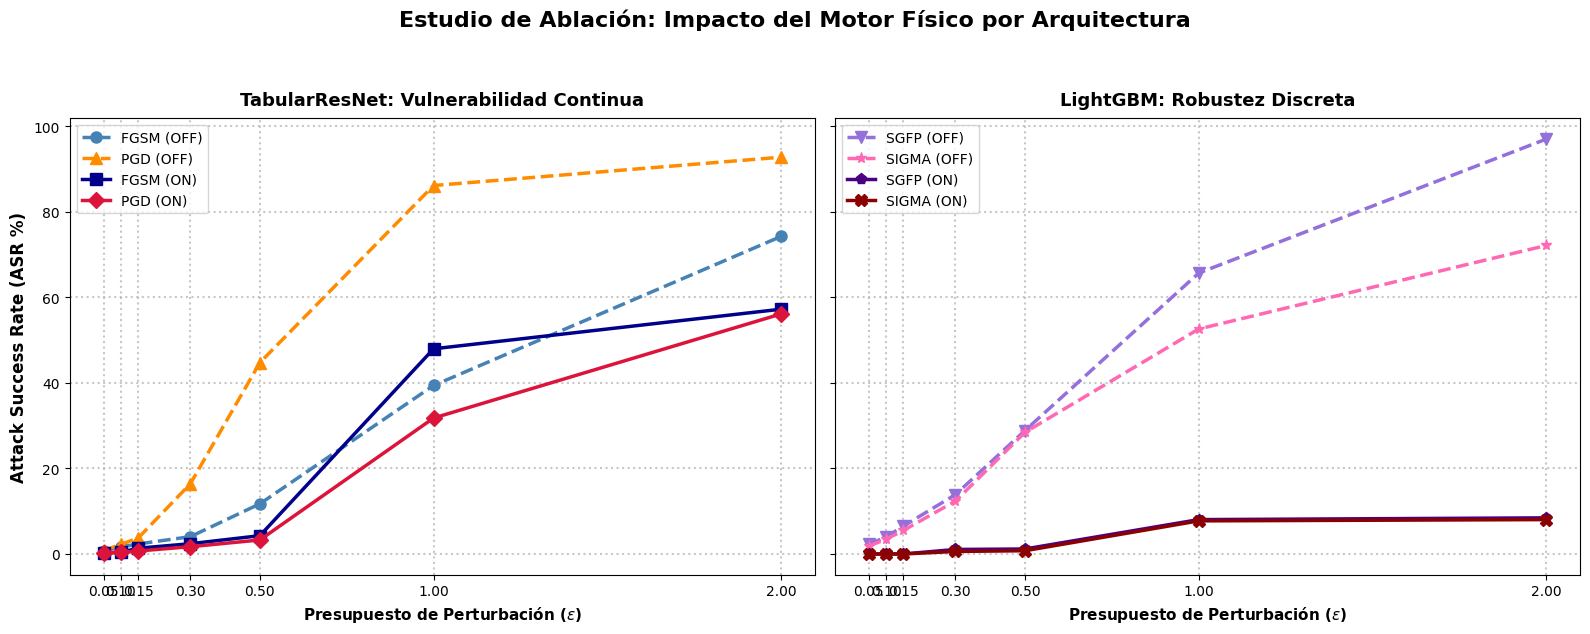

In [20]:
df_ablacion = pd.DataFrame(resultados_ablacion)
df_ablacion['Escenario'] = df_ablacion['Escenario'].replace('OFF (Solo Math)', 'OFF (Math)')

# Creamos 2 subgráficos (1 fila, 2 columnas) compartiendo el eje Y
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- CONFIGURACIÓN VISUAL (AÑADIDO SIGMA) ---
estilos = {
    'OFF (Math)_FGSM (ResNet)':     {'color': 'steelblue',  'marker': 'o', 'ls': '--', 'label': 'FGSM (OFF)'},
    'ON (Motor Físico)_FGSM (ResNet)':  {'color': 'darkblue',   'marker': 's', 'ls': '-',  'label': 'FGSM (ON)'},
    'OFF (Math)_PGD (ResNet)':      {'color': 'darkorange', 'marker': '^', 'ls': '--', 'label': 'PGD (OFF)'},
    'ON (Motor Físico)_PGD (ResNet)':   {'color': 'crimson',    'marker': 'D', 'ls': '-',  'label': 'PGD (ON)'},

    'OFF (Math)_SGFP (LightGBM)':   {'color': 'mediumpurple','marker': 'v', 'ls': '--', 'label': 'SGFP (OFF)'},
    'ON (Motor Físico)_SGFP (LightGBM)':{'color': 'indigo',     'marker': 'p', 'ls': '-',  'label': 'SGFP (ON)'},
    'OFF (Math)_SIGMA (LightGBM)':  {'color': 'hotpink',    'marker': '*', 'ls': '--', 'label': 'SIGMA (OFF)'},
    'ON (Motor Físico)_SIGMA (LightGBM)':{'color': 'darkred',   'marker': 'X', 'ls': '-',  'label': 'SIGMA (ON)'}
}

def dibujar_lineas(ax, ataques_filtrar, titulo):
    for escenario in ['OFF (Math)', 'ON (Motor Físico)']:
        for ataque in ataques_filtrar:
            key = f"{escenario}_{ataque}"
            subset = df_ablacion[(df_ablacion['Escenario'] == escenario) & (df_ablacion['Ataque'] == ataque)]
            if not subset.empty:
                ax.plot(
                    subset['Epsilon'], subset['ASR (%)'],
                    label=estilos[key]['label'], color=estilos[key]['color'],
                    marker=estilos[key]['marker'], linestyle=estilos[key]['ls'],
                    linewidth=2.5, markersize=8
                )
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Presupuesto de Perturbación ($\epsilon$)', fontsize=11, fontweight='bold')
    ax.set_xticks(epsilons)
    ax.grid(True, linestyle=':', linewidth=1.5, alpha=0.7)
    ax.legend(fontsize='10', loc='upper left')

# Panel Izquierdo: ResNet
dibujar_lineas(axes[0], ['FGSM (ResNet)', 'PGD (ResNet)'], 'TabularResNet: Vulnerabilidad Continua')
axes[0].set_ylabel('Attack Success Rate (ASR %)', fontsize=12, fontweight='bold')

# Panel Derecho: LightGBM
dibujar_lineas(axes[1], ['SGFP (LightGBM)', 'SIGMA (LightGBM)'], 'LightGBM: Robustez Discreta')

fig.suptitle('Estudio de Ablación: Impacto del Motor Físico por Arquitectura', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## **5. Visualización Avanzada: Anatomía Forense Multimodelo**
Para comprender visualmente el "engaño" de los ataques sin restricciones, analizaremos un flujo de ataque individual frente a todo nuestro arsenal (FGSM, PGD y SGFP). Abandonamos las representaciones abstractas para adoptar un enfoque de auditoría forense estricta.

Veremos cómo los tres ataques matemáticos (Física OFF) intentan alterar variables prohibidas (ej. manipular banderas TCP de respuesta o inflar el volumen del servidor) para evadir a la IA, y cómo el motor físico (Física ON) intercepta las mutaciones imposibles en todas las arquitecturas.

### 5.1 La Deformación del Espacio Físico (Gráfico de Radar)

**Auditoria semántica L4/L7**

Buscamos una muestra representativa y comparamos las perturbaciones ($\Delta$) generadas por cada algoritmo frente al escudo físico.

In [21]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

print("INICIANDO AUDITORÍA FORENSE DUAL (L4/L7)...")

# =====================================================================
# 🕵️‍♂️ AUDITORÍA 1: TabularResNet (Ataques en Espacio Continuo)
# =====================================================================
display(HTML("<h3>📊 Auditoría 1: Vulnerabilidades en TabularResNet (FGSM vs PGD)</h3>"))

# 1. Buscar el mejor caso para ResNet
conf_orig_rn = model_wrapped.predict_proba(X_ataques)[:, 1]
conf_off_pgd = model_wrapped.predict_proba(res_pgd_off.X_adv)[:, 1]
conf_on_pgd  = model_wrapped.predict_proba(res_pgd_on.X_adv)[:, 1]

casos_rn = np.where((conf_orig_rn > 0.8) & (conf_off_pgd < 0.5) & (conf_on_pgd > 0.8))[0]
idx_rn = casos_rn[0] if len(casos_rn) > 0 else 0
print(f"   ↳ Flujo de Red Seleccionado para ResNet: #{idx_rn}")

# 2. Desescalar valores
x_orig_rn  = dc.to_physical_space(X_ataques[idx_rn:idx_rn+1])[0]
x_off_fgsm = dc.to_physical_space(res_fgsm_off.X_adv[idx_rn:idx_rn+1])[0]
x_off_pgd  = dc.to_physical_space(res_pgd_off.X_adv[idx_rn:idx_rn+1])[0]
x_on_fgsm  = dc.to_physical_space(res_fgsm_on.X_adv[idx_rn:idx_rn+1])[0]
x_on_pgd   = dc.to_physical_space(res_pgd_on.X_adv[idx_rn:idx_rn+1])[0]

data_rn = []
for i, feat in enumerate(dc.feature_names):
    d_fgsm = x_off_fgsm[i] - x_orig_rn[i]
    d_pgd  = x_off_pgd[i] - x_orig_rn[i]
    d_on_max = max(abs(x_on_fgsm[i] - x_orig_rn[i]), abs(x_on_pgd[i] - x_orig_rn[i]))

    if max(abs(d_fgsm), abs(d_pgd)) > 1e-2:
        es_modificable = dc.perturbable_mask[i]
        tipo_var = "🟢 Forward" if es_modificable else "🔴 Backward/Inmutable"

        estado_ace = "🛡️ BLOQUEADO" if not es_modificable and d_on_max < 1e-2 else "OK"
        if not es_modificable and estado_ace == "OK" and max(abs(d_fgsm), abs(d_pgd)) > 1e-2:
            estado_ace = "🚨 ALERTA LÓGICA"

        data_rn.append({
            'Característica': feat,
            'Tipo': tipo_var,
            'Valor Original': x_orig_rn[i],
            'Δ FGSM (OFF)': d_fgsm,
            'Δ PGD (OFF)': d_pgd,
            'Motor Físico (ON)': estado_ace
        })

df_rn = pd.DataFrame(data_rn)
display(df_rn.style.format({
    'Valor Original': "{:.1f}", 'Δ FGSM (OFF)': "{:+.1f}", 'Δ PGD (OFF)': "{:+.1f}"
}).map(lambda x: 'color: green; font-weight: bold;' if x == '🛡️ BLOQUEADO' else
                    ('color: red; font-weight: bold;' if x == '🚨 ALERTA LÓGICA' else ''),
            subset=['Motor Físico (ON)']))


# =====================================================================
# 🕵️‍♂️ AUDITORÍA 2: LightGBM (Ataques Guiados por SHAP)
# =====================================================================
display(HTML("<hr><h3>📊 Auditoría 2: Vulnerabilidades en LightGBM (SGFP vs SIGMA)</h3>"))

# 1. Buscar el mejor caso específico para LightGBM
conf_orig_lgbm = lgbm_wrapper.predict_proba(X_ataques)[:, 1]
conf_off_sigma = lgbm_wrapper.predict_proba(res_sigma_off.X_adv)[:, 1]
conf_on_sigma  = lgbm_wrapper.predict_proba(res_sigma_on.X_adv)[:, 1]

casos_lgbm = np.where((conf_orig_lgbm > 0.8) & (conf_off_sigma < 0.5) & (conf_on_sigma > 0.8))[0]
idx_lgbm = casos_lgbm[0] if len(casos_lgbm) > 0 else 0
print(f"   ↳ Flujo de Red Seleccionado para LightGBM: #{idx_lgbm}")

# 2. Desescalar valores
x_orig_lgbm = dc.to_physical_space(X_ataques[idx_lgbm:idx_lgbm+1])[0]
x_off_sgfp  = dc.to_physical_space(res_sgfp_off.X_adv[idx_lgbm:idx_lgbm+1])[0]
x_off_sigma = dc.to_physical_space(res_sigma_off.X_adv[idx_lgbm:idx_lgbm+1])[0]
x_on_sgfp   = dc.to_physical_space(res_sgfp_on.X_adv[idx_lgbm:idx_lgbm+1])[0]
x_on_sigma  = dc.to_physical_space(res_sigma_on.X_adv[idx_lgbm:idx_lgbm+1])[0]

data_lgbm = []
for i, feat in enumerate(dc.feature_names):
    d_sgfp  = x_off_sgfp[i] - x_orig_lgbm[i]
    d_sigma = x_off_sigma[i] - x_orig_lgbm[i]
    d_on_max = max(abs(x_on_sgfp[i] - x_orig_lgbm[i]), abs(x_on_sigma[i] - x_orig_lgbm[i]))

    if max(abs(d_sgfp), abs(d_sigma)) > 1e-2:
        es_modificable = dc.perturbable_mask[i]
        tipo_var = "🟢 Forward" if es_modificable else "🔴 Backward/Inmutable"

        estado_ace = "🛡️ BLOQUEADO" if not es_modificable and d_on_max < 1e-2 else "OK"
        if not es_modificable and estado_ace == "OK" and max(abs(d_sgfp), abs(d_sigma)) > 1e-2:
            estado_ace = "🚨 ALERTA LÓGICA"

        data_lgbm.append({
            'Característica': feat,
            'Tipo': tipo_var,
            'Valor Original': x_orig_lgbm[i],
            'Δ SGFP (OFF)': d_sgfp,
            'Δ SIGMA (OFF)': d_sigma,
            'Motor Físico (ON)': estado_ace
        })

df_lgbm = pd.DataFrame(data_lgbm)
display(df_lgbm.style.format({
    'Valor Original': "{:.1f}", 'Δ SGFP (OFF)': "{:+.1f}", 'Δ SIGMA (OFF)': "{:+.1f}"
}).map(lambda x: 'color: green; font-weight: bold;' if x == '🛡️ BLOQUEADO' else
                    ('color: red; font-weight: bold;' if x == '🚨 ALERTA LÓGICA' else ''),
            subset=['Motor Físico (ON)']))

INICIANDO AUDITORÍA FORENSE DUAL (L4/L7)...


   ↳ Flujo de Red Seleccionado para ResNet: #123


,Característica,Tipo,Valor Original,Δ FGSM (OFF),Δ PGD (OFF),Motor Físico (ON)
0,L4_DST_PORT,🔴 Backward/Inmutable,80.0,+42996.3,+2143.7,🛡️ BLOQUEADO
1,PROTOCOL,🔴 Backward/Inmutable,6.0,+11.0,+11.0,🛡️ BLOQUEADO
2,L7_PROTO,🔴 Backward/Inmutable,7.0,+85.0,+0.0,🛡️ BLOQUEADO
3,IN_BYTES,🟢 Forward,700.0,-660.0,-640.0,OK
4,IN_PKTS,🟢 Forward,5.0,-4.0,-4.0,OK
5,OUT_BYTES,🔴 Backward/Inmutable,80.0,-80.0,+15.0,🛡️ BLOQUEADO
6,OUT_PKTS,🔴 Backward/Inmutable,2.0,+21.0,+21.0,🛡️ BLOQUEADO
7,TCP_FLAGS,🔴 Backward/Inmutable,22.0,-22.0,-22.0,🛡️ BLOQUEADO
8,CLIENT_TCP_FLAGS,🔴 Backward/Inmutable,2.0,-2.0,+16.0,🛡️ BLOQUEADO
9,SERVER_TCP_FLAGS,🔴 Backward/Inmutable,20.0,-20.0,+7.0,🛡️ BLOQUEADO


   ↳ Flujo de Red Seleccionado para LightGBM: #0


,Característica,Tipo,Valor Original,Δ SGFP (OFF),Δ SIGMA (OFF),Motor Físico (ON)
0,L4_DST_PORT,🔴 Backward/Inmutable,80.0,-59.0,-59.0,🛡️ BLOQUEADO
1,L7_PROTO,🔴 Backward/Inmutable,7.0,+0.0,+85.0,🛡️ BLOQUEADO
2,TCP_FLAGS,🔴 Backward/Inmutable,20.0,+0.0,-20.0,🛡️ BLOQUEADO
3,DURATION_PER_PKT,🔴 Backward/Inmutable,1.0,+3614.5,+58.9,🛡️ BLOQUEADO
4,FLOW_RANK_IN_IP,🔴 Backward/Inmutable,0.0,+0.7,+0.1,🛡️ BLOQUEADO
5,BUF_UNIQUE_DST_IPS,🔴 Backward/Inmutable,1.0,+98.0,+98.0,🛡️ BLOQUEADO
6,BUF_FLOW_COUNT,🔴 Backward/Inmutable,82.0,-82.0,-82.0,🛡️ BLOQUEADO
7,BUF_SCAN_RATE,🔴 Backward/Inmutable,0.8,+1486.1,+1486.1,🛡️ BLOQUEADO
8,BUF_SMALL_PKT_RATIO,🔴 Backward/Inmutable,0.1,+0.9,+0.5,🛡️ BLOQUEADO
9,BUF_HTTP_BYTES_AVG,🔴 Backward/Inmutable,194.0,-194.0,-194.0,🛡️ BLOQUEADO


### **5.2. Rastreadores Tácticos: Simulación de Evasión en Tiempo Real**

Analizamos la dinámica de la caída de confianza a medida que el ataque inyecta mutaciones iterativas sobre las variables más vulnerables. Hemos implementado un generador funcional que nos permite simular cualquier vector de ataque (PGD sobre ResNet o SGFP sobre LightGBM).

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("[-] Generando Simuladores Visuales Tácticos (Para la Presentación del TFG)...")

# 1. Buscar el mejor caso específico para ResNet (PGD)
conf_orig_rn = model_wrapped.predict_proba(X_ataques)[:, 1]
conf_off_pgd = model_wrapped.predict_proba(res_pgd_off.X_adv)[:, 1]
conf_on_pgd  = model_wrapped.predict_proba(res_pgd_on.X_adv)[:, 1]

casos_rn = np.where((conf_orig_rn > 0.8) & (conf_off_pgd < 0.5) & (conf_on_pgd > 0.8))[0]
idx_rn = casos_rn[0] if len(casos_rn) > 0 else 0

# 2. Buscar el mejor caso específico para LightGBM (SIGMA)
conf_orig_lgbm = lgbm_wrapper.predict_proba(X_ataques)[:, 1]
conf_off_sigma = lgbm_wrapper.predict_proba(res_sigma_off.X_adv)[:, 1]
conf_on_sigma  = lgbm_wrapper.predict_proba(res_sigma_on.X_adv)[:, 1]

casos_lgbm = np.where((conf_orig_lgbm > 0.8) & (conf_off_sigma < 0.5) & (conf_on_sigma > 0.8))[0]
idx_lgbm = casos_lgbm[0] if len(casos_lgbm) > 0 else 0


# ==========================================
# SIMULADORES TÁCTICOS (PLOTLY ANIMADO)
# ==========================================
def crear_simulador_tactico(idx, res_off, res_on, model, attack_name):
    """Genera un dashboard interactivo simulando la trayectoria de evasión."""
    orig_pt = X_ataques[idx]
    off_pt = res_off.X_adv[idx]
    on_pt = res_on.X_adv[idx]

    # Coger las 5 variables más mutadas para el gráfico de barras
    deltas_totales = np.abs(off_pt - orig_pt)
    top_idx = np.argsort(deltas_totales)[-5:]
    feat_names = [dc.feature_names[i] for i in top_idx]

    # Crear trayectoria suavizada (Interpolación)
    n_frames = 30
    ease_out = 1 - (1 - np.linspace(0, 1, n_frames))**3
    traj_off = np.array([orig_pt + (off_pt - orig_pt) * step for step in ease_out])
    traj_on  = np.array([orig_pt + (on_pt - orig_pt) * step for step in ease_out])

    # Calcular confianzas en cada frame
    conf_off_t = model.predict_proba(traj_off)[:, 1] * 100
    conf_on_t  = model.predict_proba(traj_on)[:, 1] * 100

    iterations = np.arange(1, n_frames + 1)
    
    # Valores físicos para el gráfico de barras
    orig_phys = dc.to_physical_space(np.array([orig_pt]))[0]
    traj_off_phys = dc.to_physical_space(traj_off)
    
    max_delta_phys = np.max(np.abs(traj_off_phys[-1, top_idx] - orig_phys[top_idx]))
    if max_delta_phys == 0: max_delta_phys = 1.0

    fig = make_subplots(rows=1, cols=2, column_widths=[0.6, 0.4],
                        subplot_titles=(f"Confianza: {attack_name}", "Mutación Interna (Ataque OFF)"),
                        horizontal_spacing=0.15)

    # Trazos iniciales
    fig.add_trace(go.Scatter(x=[iterations[0]], y=[conf_off_t[0]], mode='lines+markers', name='Bypass (OFF)', line=dict(color='orange', width=4)), row=1, col=1)
    fig.add_trace(go.Scatter(x=[iterations[0]], y=[conf_on_t[0]], mode='lines+markers', name='Escudo (ON)', line=dict(color='crimson', width=4)), row=1, col=1)
    fig.add_trace(go.Bar(y=feat_names, x=traj_off_phys[0, top_idx] - orig_phys[top_idx], orientation='h', marker_color='orange', name='Mutación'), row=1, col=2)
    fig.add_hline(y=50, line_dash="dash", line_color="gray", row=1, col=1)

    # Generar los frames de la animación
    frames = []
    for k in range(1, n_frames):
        frames.append(go.Frame(data=[
                go.Scatter(x=iterations[:k], y=conf_off_t[:k]),
                go.Scatter(x=iterations[:k], y=conf_on_t[:k]),
                go.Bar(x=traj_off_phys[k, top_idx] - orig_phys[top_idx])
            ],
            name=str(k),
            traces=[0, 1, 2]
        ))
    fig.frames = frames

    # Layout y Botón de Play
    fig.update_layout(template="plotly_dark", title=f"<b>▶ RASTREADOR TÁCTICO: {attack_name} (Flujo #{idx})</b>",
                      paper_bgcolor="#0a0a0a", plot_bgcolor="#0a0a0a", legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1),
                      xaxis=dict(range=[0, n_frames], title="Progreso de Inyección"), yaxis=dict(range=[0, 105], title="Confianza de Ataque (%)"),
                      xaxis2=dict(range=[-max_delta_phys*1.2, max_delta_phys*1.2], title="Perturbación (Unidades Físicas)"),
                      updatemenus=[dict(type="buttons", showactive=False, x=0.5, y=-0.2, xanchor="center", direction="right",
                                        buttons=[dict(label="▶ REPRODUCIR ATAQUE", method="animate", args=[None, dict(frame=dict(duration=120, redraw=True), transition=dict(duration=50), fromcurrent=True, mode="immediate")])],
                                        bgcolor="crimson", font=dict(color="white"))])
    return fig

# --- RENDERIZAR GRÁFICOS ---
# Simulador 1: PGD contra la ResNet (Usando el índice óptimo para la red)
fig_pgd = crear_simulador_tactico(idx_rn, res_pgd_off, res_pgd_on, model_wrapped, "PGD vs ResNet")
fig_pgd.show()

# Simulador 2: SIGMA contra LightGBM (Usando el índice óptimo para los árboles)
fig_sigma = crear_simulador_tactico(idx_lgbm, res_sigma_off, res_sigma_on, lgbm_wrapper, "SIGMA vs LightGBM")
fig_sigma.show()

[-] Generando Simuladores Visuales Tácticos (Para la Presentación del TFG)...


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## **Transferibilidad Cruzada**
### Ataques de ResNet lanzados a LightGBM y viceversa

🔄 Calculando efectividad de los ataques transferidos (OFF y ON)...


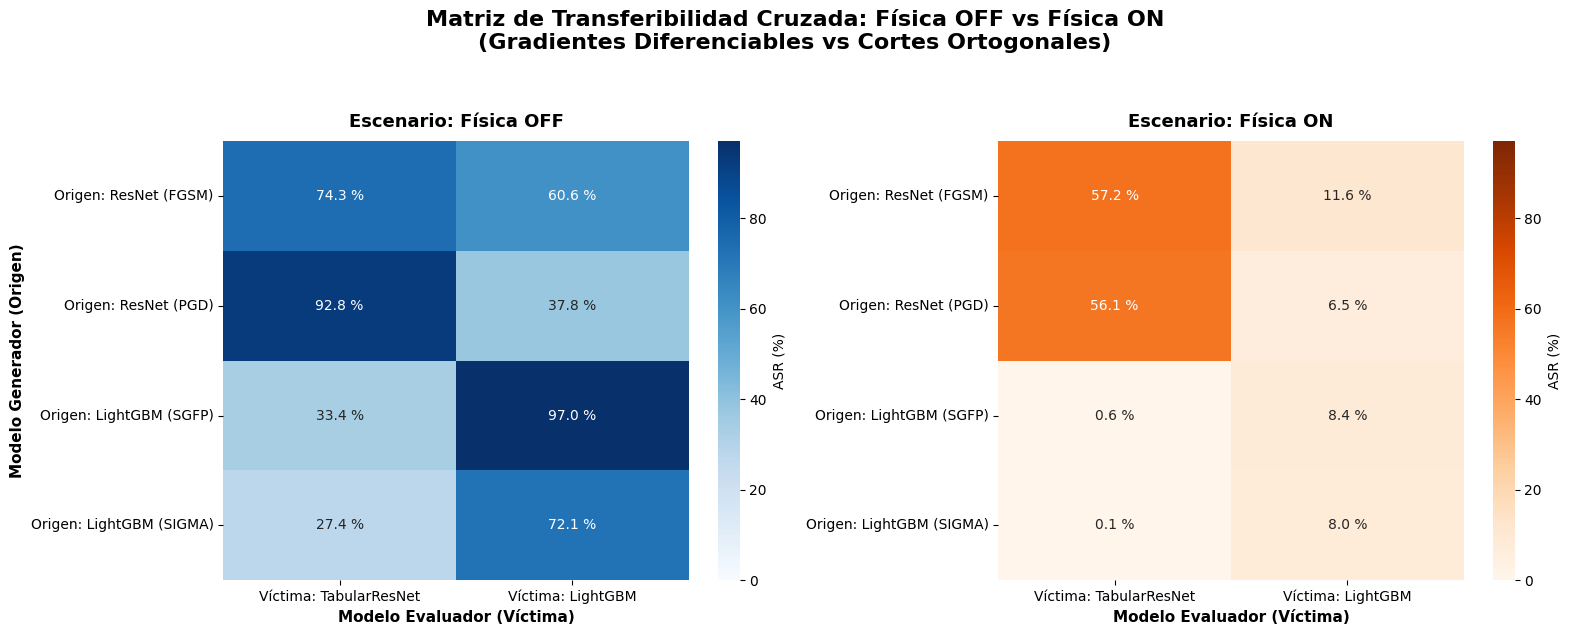


[!] Análisis de Impacto de las Restricciones Físicas (OFF -> ON):
 ↳ PGD (ResNet) a LightGBM : 37.8% (OFF)  -->  6.5% (ON)
 ↳ SIGMA (LGBM) a ResNet   : 27.4% (OFF)  -->  0.1% (ON)


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, HTML

display(HTML("<h2>6. Análisis de Transferibilidad Cruzada (Física OFF vs Física ON)</h2>"))
print("🔄 Calculando efectividad de los ataques transferidos (OFF y ON)...")

# 1. Función para calcular el ASR transferido
def asr_transferido(modelo_victima, X_adv_origen, y_reales):
    y_pred = modelo_victima.predict(X_adv_origen)
    evasiones = np.sum(y_pred == 0)
    return (evasiones / len(y_reales)) * 100

# ==========================================
# BLOQUE 1: CÁLCULOS FÍSICA OFF
# ==========================================
trans_fgsm_to_lgbm_off = asr_transferido(lgbm_wrapper, res_fgsm_off.X_adv, y_ataques)
trans_pgd_to_lgbm_off  = asr_transferido(lgbm_wrapper, res_pgd_off.X_adv, y_ataques)
trans_sgfp_to_rn_off   = asr_transferido(model_wrapped, res_sgfp_off.X_adv, y_ataques)
trans_sigma_to_rn_off  = asr_transferido(model_wrapped, res_sigma_off.X_adv, y_ataques)

data_transfer_off = {
    "Víctima: TabularResNet": [
        res_fgsm_off.asr * 100, 
        res_pgd_off.asr * 100, 
        trans_sgfp_to_rn_off, 
        trans_sigma_to_rn_off
    ],
    "Víctima: LightGBM": [
        trans_fgsm_to_lgbm_off, 
        trans_pgd_to_lgbm_off, 
        res_sgfp_off.asr * 100, 
        res_sigma_off.asr * 100
    ]
}

# ==========================================
# BLOQUE 2: CÁLCULOS FÍSICA ON
# ==========================================
trans_fgsm_to_lgbm_on = asr_transferido(lgbm_wrapper, res_fgsm_on.X_adv, y_ataques)
trans_pgd_to_lgbm_on  = asr_transferido(lgbm_wrapper, res_pgd_on.X_adv, y_ataques)
trans_sgfp_to_rn_on   = asr_transferido(model_wrapped, res_sgfp_on.X_adv, y_ataques)
trans_sigma_to_rn_on  = asr_transferido(model_wrapped, res_sigma_on.X_adv, y_ataques)

data_transfer_on = {
    "Víctima: TabularResNet": [
        res_fgsm_on.asr * 100, 
        res_pgd_on.asr * 100, 
        trans_sgfp_to_rn_on, 
        trans_sigma_to_rn_on
    ],
    "Víctima: LightGBM": [
        trans_fgsm_to_lgbm_on, 
        trans_pgd_to_lgbm_on, 
        res_sgfp_on.asr * 100, 
        res_sigma_on.asr * 100
    ]
}

labels = [
    "Origen: ResNet (FGSM)", 
    "Origen: ResNet (PGD)", 
    "Origen: LightGBM (SGFP)", 
    "Origen: LightGBM (SIGMA)"
]

df_trans_off = pd.DataFrame(data_transfer_off, index=labels)
df_trans_on = pd.DataFrame(data_transfer_on, index=labels)

# ==========================================
# BLOQUE 3: VISUALIZACIÓN (Subplots 1x2 con colores distintos)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Usamos un vmax unificado para mantener la proporción visual entre ambos escenarios
vmax_global = max(df_trans_off.max().max(), df_trans_on.max().max(), 10.0)

# Heatmap 1: Física OFF (Azules)
sns.heatmap(df_trans_off, annot=True, fmt=".1f", cmap="Blues", 
            cbar_kws={'label': 'ASR (%)'}, vmin=0, vmax=vmax_global, ax=axes[0])
axes[0].set_title("Escenario: Física OFF", fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel("Modelo Generador (Origen)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Modelo Evaluador (Víctima)", fontsize=11, fontweight='bold')

# Heatmap 2: Física ON (Naranjas) - CAMBIO DE COLOR AQUÍ
sns.heatmap(df_trans_on, annot=True, fmt=".1f", cmap="Oranges", 
            cbar_kws={'label': 'ASR (%)'}, vmin=0, vmax=vmax_global, ax=axes[1])
axes[1].set_title("Escenario: Física ON", fontsize=13, fontweight='bold', pad=10)
axes[1].set_ylabel("") # Quitamos el label Y para no ensuciar
axes[1].set_xlabel("Modelo Evaluador (Víctima)", fontsize=11, fontweight='bold')

# Añadir sufijo % a las celdas en ambos subplots
for ax in axes:
    for t in ax.texts:
        t.set_text(t.get_text() + " %")

# Título general
plt.suptitle("Matriz de Transferibilidad Cruzada: Física OFF vs Física ON\n(Gradientes Diferenciables vs Cortes Ortogonales)", 
             fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

# ==========================================
# BLOQUE 4: OUTPUT DE TEXTO COMPARATIVO
# ==========================================
print("\n[!] Análisis de Impacto de las Restricciones Físicas (OFF -> ON):")
print(f" ↳ PGD (ResNet) a LightGBM : {trans_pgd_to_lgbm_off:.1f}% (OFF)  -->  {trans_pgd_to_lgbm_on:.1f}% (ON)")
print(f" ↳ SIGMA (LGBM) a ResNet   : {trans_sigma_to_rn_off:.1f}% (OFF)  -->  {trans_sigma_to_rn_on:.1f}% (ON)")

## 6. Visualización del Espacio Latente: La Infiltración Adversarial (PCA 3D)

Reducimos la dimensionalidad de las 66 features a espacio 3D mediante PCA para observar el efecto de la ablación en el espacio de características.
Observaremos tres comportamientos:
1. **Nube Azul (Benigno):** El destino al que quiere llegar el ataque.
2. **Puntos Rojos (Originales):** Los ataques iniciales bloqueados.
3. **Trayectoria Amarilla (PGD OFF):** El ataque puramente matemático vuela directo hacia la zona benigna (haciendo trampas L4/L7).
4. **Trayectoria Verde (PGD ON):** Al aplicar el Motor Físico, el ataque se frena y se queda atrapado en la zona de detección, evidenciando el *Gradient Masking*.

Extrayendo confidencias de ambos modelos...


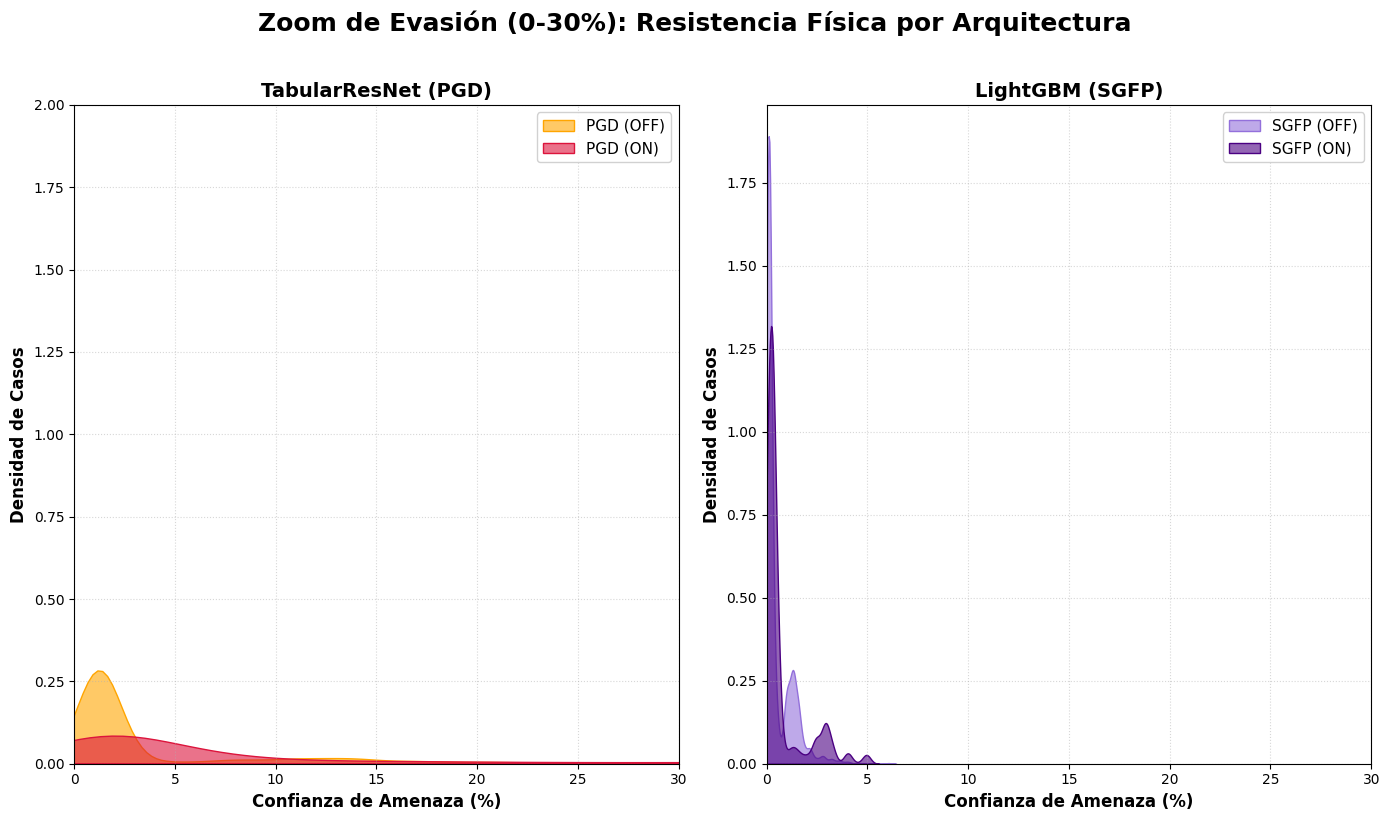

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# 1. Lienzo más alto (14, 8) y ejes independientes (sharey=False) para que no se aplasten
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=False)

print("Extrayendo confidencias de ambos modelos...")
with torch.no_grad():
    # Confianzas ResNet (PGD)
    rn_off = model_wrapped.predict_proba(res_pgd_off.X_adv)[:, 1] * 100
    rn_on  = model_wrapped.predict_proba(res_pgd_on.X_adv)[:, 1] * 100

    # Confianzas LightGBM (SGFP)
    lgbm_off = lgbm_wrapper.predict_proba(res_sgfp_off.X_adv)[:, 1] * 100
    lgbm_on  = lgbm_wrapper.predict_proba(res_sgfp_on.X_adv)[:, 1] * 100

# Panel Izquierdo: ResNet (Volvemos a las curvas suaves KDE)
sns.kdeplot(rn_off, ax=axes[0], fill=True, color="orange", label="PGD (OFF)", bw_adjust=0.8, alpha=0.6)
sns.kdeplot(rn_on,  ax=axes[0], fill=True, color="crimson", label="PGD (ON)", bw_adjust=0.8, alpha=0.6)
axes[0].set_xlim(0, 30)
axes[0].set_ylim(0, 2)
axes[0].set_title('TabularResNet (PGD)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Confianza de Amenaza (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Densidad de Casos', fontsize=12, fontweight='bold')
axes[0].grid(axis='both', linestyle=':', alpha=0.5)
axes[0].legend(loc='upper right', framealpha=0.9, fontsize=11)

# Panel Derecho: LightGBM
sns.kdeplot(lgbm_off, ax=axes[1], fill=True, color="mediumpurple", label="SGFP (OFF)", bw_adjust=0.8, alpha=0.6)
sns.kdeplot(lgbm_on,  ax=axes[1], fill=True, color="indigo", label="SGFP (ON)", bw_adjust=0.8, alpha=0.6)
axes[1].set_xlim(0, 30)
axes[0].set_ylim(0, 2)
axes[1].set_title('LightGBM (SGFP)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Confianza de Amenaza (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Densidad de Casos', fontsize=12, fontweight='bold') # Le ponemos etiqueta también
axes[1].grid(axis='both', linestyle=':', alpha=0.5)
axes[1].legend(loc='upper right', framealpha=0.9, fontsize=11)

fig.suptitle('Zoom de Evasión (0-30%): Resistencia Física por Arquitectura', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## TABLA AUDITORÍA FORENSE L4/L7

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("🕵️‍♂️ INICIANDO AUDITORÍA FORENSE L4/L7...")

# 1. Buscar el "Culpable Perfecto" (OFF evade, ON es bloqueado)
conf_orig = model_wrapped.predict_proba(X_ataques)[:, 1]
conf_off = model_wrapped.predict_proba(res_pgd_off.X_adv)[:, 1]
conf_on = model_wrapped.predict_proba(res_pgd_on.X_adv)[:, 1]

casos_perfectos = np.where((conf_orig > 0.8) & (conf_off < 0.5) & (conf_on > 0.8))[0]
idx_target = casos_perfectos[0] if len(casos_perfectos) > 0 else 0

print(f"🎯 Flujo Seleccionado: #{idx_target}")
print(f"   -> Confianza Original: {conf_orig[idx_target]*100:.1f}% (Detectado)")
print(f"   -> Confianza PGD OFF : {conf_off[idx_target]*100:.1f}% (Bypass OFF)")
print(f"   -> Confianza PGD ON  : {conf_on[idx_target]*100:.1f}% (Bloqueado ON)")

# 2. Desescalar valores al espacio físico real
x_orig_phys = dc.to_physical_space(X_ataques[idx_target:idx_target+1])[0]
x_off_phys  = dc.to_physical_space(res_pgd_off.X_adv[idx_target:idx_target+1])[0]
x_on_phys   = dc.to_physical_space(res_pgd_on.X_adv[idx_target:idx_target+1])[0]

# 3. Construir la Tabla usando tu objeto 'dc'
feature_names = dc.feature_names
data_forense = []

for i, feat in enumerate(feature_names):
    val_orig = x_orig_phys[i]
    val_off = x_off_phys[i]
    val_on = x_on_phys[i]

    delta_off = val_off - val_orig
    delta_on = val_on - val_orig

    # Solo mostramos características que han sido modificadas para no saturar
    if abs(delta_off) > 1e-2 or abs(delta_on) > 1e-2:
        # dc.perturbable_mask nos dice si la variable se puede tocar legalmente
        es_modificable = dc.perturbable_mask[i]
        tipo_var = "🟢 Forward" if es_modificable else "🔴 Backward/Inmutable"

        status_off = "🚨 ILEGAL" if not es_modificable and abs(delta_off) > 1e-2 else "OK"
        status_on = "🛡️ BLOQUEADO" if not es_modificable and abs(delta_on) < 1e-2 and abs(delta_off) > 1e-2 else "OK"

        data_forense.append({
            'Característica': feat,
            'Tipo': tipo_var,
            'Original': val_orig,
            'PGD (OFF)': val_off,
            'Δ OFF': delta_off,
            'Estado OFF': status_off,
            'PGD (ON)': val_on,
            'Δ ON': delta_on,
            'Estado ON': status_on
        })

df_forense = pd.DataFrame(data_forense)

# Mostrar Tabla
display(df_forense.style.format({
    'Original': "{:.1f}", 'PGD (OFF)': "{:.1f}", 'Δ OFF': "{:+.1f}",
    'PGD (ON)': "{:.1f}", 'Δ ON': "{:+.1f}"
}).applymap(lambda x: 'color: red; font-weight: bold;' if x == '🚨 ILEGAL' else
                    ('color: green; font-weight: bold;' if x == '🛡️ BLOQUEADO' else ''),
            subset=['Estado OFF', 'Estado ON']))

🕵️‍♂️ INICIANDO AUDITORÍA FORENSE L4/L7...
🎯 Flujo Seleccionado: #123
   -> Confianza Original: 91.0% (Detectado)
   -> Confianza PGD OFF : 1.4% (Bypass OFF)
   -> Confianza PGD ON  : 85.0% (Bloqueado ON)


C:\Users\Daniel\AppData\Local\Temp\ipykernel_21020\2343039861.py:64: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.



,Característica,Tipo,Original,PGD (OFF),Δ OFF,Estado OFF,PGD (ON),Δ ON,Estado ON
0,L4_DST_PORT,🔴 Backward/Inmutable,80.0,2223.7,+2143.7,🚨 ILEGAL,80.0,+0.0,🛡️ BLOQUEADO
1,PROTOCOL,🔴 Backward/Inmutable,6.0,17.0,+11.0,🚨 ILEGAL,6.0,+0.0,🛡️ BLOQUEADO
2,IN_BYTES,🟢 Forward,700.0,60.0,-640.0,OK,27183.9,+26483.9,OK
3,IN_PKTS,🟢 Forward,5.0,1.0,-4.0,OK,105.0,+100.0,OK
4,OUT_BYTES,🔴 Backward/Inmutable,80.0,95.0,+15.0,🚨 ILEGAL,80.0,+0.0,🛡️ BLOQUEADO
5,OUT_PKTS,🔴 Backward/Inmutable,2.0,23.0,+21.0,🚨 ILEGAL,2.0,+0.0,🛡️ BLOQUEADO
6,TCP_FLAGS,🔴 Backward/Inmutable,22.0,0.0,-22.0,🚨 ILEGAL,22.0,+0.0,🛡️ BLOQUEADO
7,CLIENT_TCP_FLAGS,🔴 Backward/Inmutable,2.0,18.0,+16.0,🚨 ILEGAL,2.0,+0.0,🛡️ BLOQUEADO
8,SERVER_TCP_FLAGS,🔴 Backward/Inmutable,20.0,27.0,+7.0,🚨 ILEGAL,20.0,+0.0,🛡️ BLOQUEADO
9,FLOW_DURATION_MILLISECONDS,🟢 Forward,31249.3,31249.3,-0.0,OK,80983.3,+49734.0,OK


In [40]:
import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA

print("⚡ Generando Paisaje 3D Realista (Confidence Terrain)...")

# Seleccionamos 8 ataques para que las líneas se vean nítidas
n_plot = 8
p_orig = model_wrapped.predict_proba(X_ataques[:n_plot])[:, 1]
p_off = model_wrapped.predict_proba(res_pgd_off.X_adv[:n_plot])[:, 1]
p_on = model_wrapped.predict_proba(res_pgd_on.X_adv[:n_plot])[:, 1]

# PCA para el "suelo" de la gráfica
pca_2d = PCA(n_components=2)
coords_orig_2d = pca_2d.fit_transform(X_ataques[:n_plot])
coords_off_2d = pca_2d.transform(res_pgd_off.X_adv[:n_plot])
coords_on_2d = pca_2d.transform(res_pgd_on.X_adv[:n_plot])

fig = go.Figure()

# 1. EL PLANO DE DECISIÓN (El "Suelo de Cristal" al 50%)
fig.add_trace(go.Surface(
    x=np.linspace(-8, 8, 10), 
    y=np.linspace(-8, 8, 10), 
    z=np.full((10, 10), 0.5),
    opacity=0.2, 
    colorscale='Greys', 
    showscale=False, 
    name='Umbral 50%'
))

# 2. TRAYECTORIAS REALISTAS
for i in range(n_plot):
    # Mostrar la leyenda solo en la primera iteración para no saturar
    show_legend = True if i == 0 else False
    
    # OFF: Cae al vacío (Engaño exitoso)
    fig.add_trace(go.Scatter3d(
        x=[coords_orig_2d[i,0], coords_off_2d[i,0]],
        y=[coords_orig_2d[i,1], coords_off_2d[i,1]],
        z=[p_orig[i], p_off[i]],
        mode='lines+markers', 
        line=dict(color='orange', width=4, dash='dash'),
        marker=dict(size=4, color='orange'), 
        name='Ataque OFF (Engaño)',
        showlegend=show_legend
    ))

    # ON: Se mantiene en la cima (Frenado por física)
    fig.add_trace(go.Scatter3d(
        x=[coords_orig_2d[i,0], coords_on_2d[i,0]],
        y=[coords_orig_2d[i,1], coords_on_2d[i,1]],
        z=[p_orig[i], p_on[i]],
        mode='lines+markers', 
        line=dict(color='crimson', width=8),
        marker=dict(size=8, color='crimson', symbol='diamond'), 
        name='Ataque ON (Defendido)',
        showlegend=show_legend
    ))

# Estética de consola táctica
fig.update_layout(
    template="plotly_dark",
    title="<b>AUDITORÍA DE EVASIÓN: Paisaje de Confianza de la ResNet</b>",
    scene=dict(
        xaxis_title='Variable Tráfico A (PCA 1)', 
        yaxis_title='Variable Tráfico B (PCA 2)',
        zaxis_title='SEGURIDAD IA (0-100%)',
        zaxis=dict(range=[0, 1.05], tickformat='.0%'), # 1.05 da un poco de margen arriba
        bgcolor="#0a0a0a"
    ),
    paper_bgcolor="#0a0a0a", 
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

⚡ Generando Paisaje 3D Realista (Confidence Terrain)...


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 8. Comparativa Complementaria: Targeted vs Untargeted
Aunque nuestro enfoque principal es la evasión real (Targeted), demostramos brevemente que, bajo restricciones de red, la dispersión del ataque (Untargeted) tampoco logra romper la robustez de la TabularResNet.

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# 1. Ejecutar ataque Untargeted para la comparativa (Física ON)
fgsm_untargeted = FGSMAttack(constraints=dc, epsilon=0.2, mode='untargeted', device=device, verbose=False)
res_untarg = fgsm_untargeted.run(X_ataques, y_ataques, model_wrapped, class_names=Config.ATTACK_MAPPING)

# 2. Calcular métricas Originales (Baseline sin ataque)
# (Usamos res_fgsm_on que ya calculamos en la celda anterior)
y_pred_orig = res_fgsm_on.y_pred_orig
acc_orig = accuracy_score(y_ataques, y_pred_orig)
f1_orig = f1_score(y_ataques, y_pred_orig, average='macro')

# 3. Calcular métricas Untargeted
y_pred_untargeted = res_untarg.y_pred_adv
acc_untargeted = accuracy_score(y_ataques, y_pred_untargeted)
f1_untargeted = f1_score(y_ataques, y_pred_untargeted, average='macro')
asr_untargeted = res_untarg.asr

# 4. Calcular métricas Targeted
y_pred_targeted = res_fgsm_on.y_pred_adv
acc_targeted = accuracy_score(y_ataques, y_pred_targeted)
f1_targeted = f1_score(y_ataques, y_pred_targeted, average='macro')
asr_targeted = res_fgsm_on.asr

# --- DIBUJAR LA GRÁFICA COMPARATIVA COMPLETA ---
labels = ['Accuracy (Retención)', 'F1-Macro (Calidad)', 'ASR (Evasión)']
val_orig = [acc_orig, f1_orig, 0.0] # ASR original es 0%
val_untarg = [acc_untargeted, f1_untargeted, asr_untargeted]
val_targ = [acc_targeted, f1_targeted, asr_targeted]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, val_orig, width, label='Original (Sin Ataque)', color='steelblue')
rects2 = ax.bar(x, val_untarg, width, label='FGSM (Untargeted)', color='darkorange')
rects3 = ax.bar(x + width, val_targ, width, label='FGSM (Targeted)', color='crimson')

ax.set_ylabel('Puntuación (0.0 a 1.0)', fontsize=12, fontweight='bold')
ax.set_title(f'Degradación del NIDS: Untargeted vs Targeted (ε={0.2})', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
ax.set_ylim([0, 1.15]) # Margen extra para los números

# Función para poner los numeritos encima de las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  # 4 puntos de offset vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

print(f"[*] Incremento de ASR al usar Targeted vs Untargeted: +{(asr_targeted - asr_untargeted)*100:.2f}%")

ValueError: Found input variables with inconsistent numbers of samples: [1705, 5]